# Cuánto cuesta exigir laminaridad

**Anexo de presentación al notebook 26.** Ocho ejemplos elegidos para separar
la pérdida por una heurística de la pérdida por restringir las pruebas.

Modelo común: prior independiente, conteos exactos de infectados, posterior-zero,
utilidades no negativas, a lo sumo G personas por prueba y B pruebas por trayectoria.
Los ejemplos con historia declaran B como presupuesto **restante**.

Fuentes: perfiles y árboles en `results/precio_laminar_2026-09-21/resultados.json`.
Reproducción desde la raíz: `python -m augmented.experimento_precio_laminar`.

In [1]:
from pathlib import Path
import sys, json
from fractions import Fraction as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'augmented' / 'bm17_toy_solver.py').exists())
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results' / 'precio_laminar_2026-09-21'
datos = json.loads((RESULTS / 'resultados.json').read_text())
tabla = pd.read_csv(RESULTS / 'comparacion.csv')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

from hashlib import sha256
for path, digest in datos['source_sha256'].items():
    assert sha256((ROOT/path).read_bytes()).hexdigest() == digest, f'Regenerar resultados: cambió {path}'
display(tabla[['caso','n','B_restante','G','opt_laminar','opt_general','ratio_laminar_general']].round(6))

,caso,n,B_restante,G,opt_laminar,opt_general,ratio_laminar_general
0,Control: solo individuales,3,2,1,0.600000,0.600000,1.000000
1,Ejemplo conocido: dos pruebas,4,2,2,0.774000,0.774000,1.000000
2,Misma población: tres pruebas,4,3,2,1.074000,1.137000,0.944591
3,AB tiene conteo 1; queda una prueba,4,1,2,1.000000,1.000000,1.000000
4,AB tiene conteo 1; quedan dos pruebas,4,2,2,1.300000,1.450000,0.896552
5,Cuatro personas y grupos de tres,4,3,3,1.750000,2.000000,0.875000
6,Seis personas homogéneas,6,3,3,1.249380,1.419480,0.880167
7,Contraejemplo de la batería de cuatro,6,3,4,1.064514,1.110464,0.958621


## 1. Comparación con la misma población y el mismo presupuesto

Las fracciones de Bellman se calculan exactamente. El óptimo laminar coincide
con dos representaciones independientes: perfiles con legalidad sobre toda la
historia y el solver previo de átomos. Cada árbol se evalúa de nuevo sobre todos
los perfiles de infección de probabilidad positiva.

Los empates de los controles no demuestran que laminar sea siempre óptimo.
Los casos con brecha sí muestran que esa igualdad falla en general.

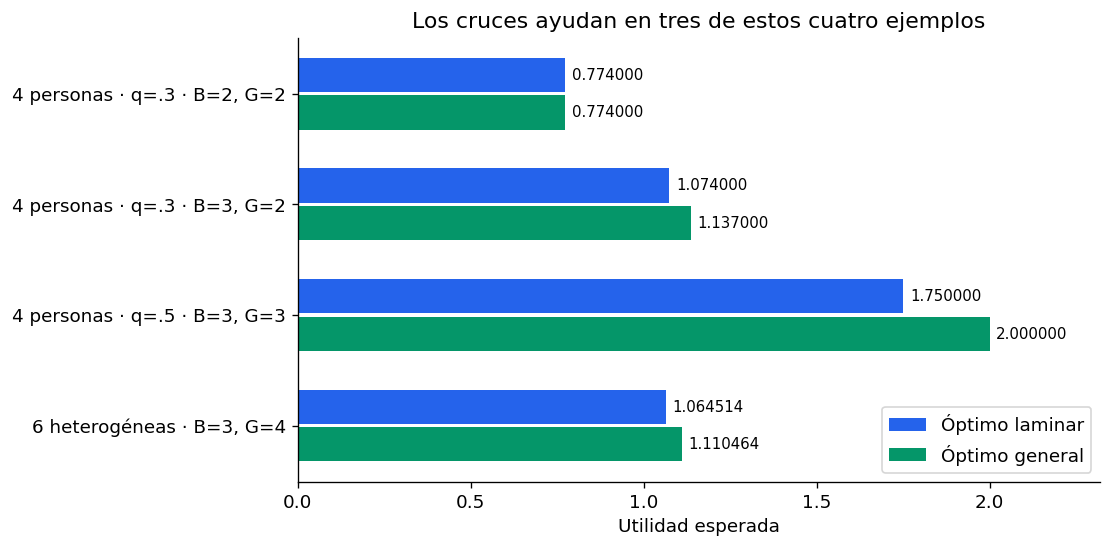

In [2]:
ids = ['par_B2', 'par_B3', 'cuatro_triples', 'seis_heterogeneo']
t = tabla.set_index('id').loc[ids]
labels = ['4 personas · q=.3 · B=2, G=2', '4 personas · q=.3 · B=3, G=2',
          '4 personas · q=.5 · B=3, G=3', '6 heterogéneas · B=3, G=4']
y=np.arange(len(ids)); fig, ax=plt.subplots(figsize=(9.4,4.7))
for delta, col, label, color in [(-.17,'opt_laminar','Óptimo laminar','#2563eb'),
                                (.17,'opt_general','Óptimo general','#059669')]:
    bars=ax.barh(y+delta,t[col],height=.31,label=label,color=color)
    ax.bar_label(bars,fmt='%.6f',padding=4,fontsize=9)
ax.set_yticks(y,labels);ax.invert_yaxis();ax.set_xlim(0,2.32)
ax.set_xlabel('Utilidad esperada');ax.legend(loc='lower right')
ax.set_title('Los cruces ayudan en tres de estos cuatro ejemplos')
fig.tight_layout();fig.savefig(RESULTS/'comparacion_optimos.png',bbox_inches='tight');plt.show()

## 2. El ejemplo conocido cambia cuando quedan tres pruebas

Cuatro personas, q=0.3, u=1, B=3, G=2. Abrimos AB.

Si R(AB)=1, quedan **dos** pruebas. El laminar puede probar A, cobrar al sano
del par y usar la última prueba en C: valor de continuación **1.3**.
El general puede cruzar **AC**:

| R(AC) | Probabilidad condicionada a R(AB)=1 | Última prueba | Utilidad total desde este estado |
|---|---:|---|---:|
| 0 | 0.15 | D | 2.3 |
| 1 | 0.50 | A | 1.3 |
| 2 | 0.35 | D | 1.3 |

Su continuación vale $0.15(2.3)+0.50(1.3)+0.35(1.3)=1.45$.
En la rama intermedia, probar A distingue (A sana, B y C infectadas) de
(A infectada, B y C sanas). D no queda identificada en esa rama.

**Ejercicio:** ¿por qué la mejora inicial no es 0.15?

<details><summary>Respuesta para comprobar después de calcular</summary>

El estado R(AB)=1 se alcanza con probabilidad 0.42. La mejora al inicio es
0.42 × (1.45 − 1.30) = **0.063**. Por eso 1.074 pasa a **1.137**.
Los otros dos resultados de AB aportan lo mismo a ambas estrategias.

</details>

In [3]:
from augmented.bellman_perfiles import BellmanPerfiles
historia = [((0,1),1)]
lam = BellmanPerfiles(['.7']*4,[1]*4,2,laminar=True)
general = BellmanPerfiles(['.7']*4,[1]*4,2)
assert lam.solve(2,historia).value == F(13,10)
assert general.solve(2,historia).value == F(29,20)
assert general.solve(2,historia).first_pool == (0,2)
assert F(42,100)*(F(29,20)-F(13,10)) == F(63,1000)
print('Con una prueba restante:', lam.solve(1,historia).value, general.solve(1,historia).value)
print('Con dos pruebas restantes:', lam.solve(2,historia).value, general.solve(2,historia).value)
print('Mejora al inicio:', F(63,1000), '= 0.063')

Con una prueba restante: 1 1
Con dos pruebas restantes: 13/10 29/20
Mejora al inicio: 63/1000 = 0.063


## 3. Tres pruebas cruzadas identifican a cuatro personas

Caso nuevo: n=4, q=0.5, u=1, B=3, G=3. Las pruebas **ABC, ABD y ACD**
se pueden fijar de antemano. Sus tres conteos distinguen los 16 perfiles posibles.
Por eso se identifica a toda persona sana y se alcanza la cota máxima
$\sum_i q_i u_i=2$. Bellman laminar da **1.75**: ratio **0.875**.

Este ejemplo muestra una ventaja de los cruces incluso con ese diseño fijo.
No es necesario atribuir toda la ganancia a la adaptación.

<details><summary>Cómo recuperar los cuatro estados a mano</summary>

Sean x=R(ABC), y=R(ABD), z=R(ACD), y a,b,c,d indicadores de infección.
Como x+y+z=3a+2(b+c+d), su paridad determina a.
Después b=(x+y−z−a)/2, c=(x+z−y−a)/2 y d=(y+z−x−a)/2.

</details>

In [4]:
certificado = datos['four_person_static_certificate']
assert len({tuple(x['counts']) for x in certificado}) == 16
display(pd.DataFrame([{'ABCD infectados': ''.join(map(str,x['profile'])),
                       'R(ABC), R(ABD), R(ACD)': tuple(x['counts'])} for x in certificado]))
print('Las 16 firmas son distintas. Recuperación total con tres pruebas.')

,ABCD infectados,"R(ABC), R(ABD), R(ACD)"
0,0000,"(0, 0, 0)"
1,1000,"(1, 1, 1)"
2,0100,"(1, 1, 0)"
3,1100,"(2, 2, 1)"
4,0010,"(1, 0, 1)"
5,1010,"(2, 1, 2)"
6,0110,"(2, 1, 1)"
7,1110,"(3, 2, 2)"
8,0001,"(0, 1, 1)"
9,1001,"(1, 2, 2)"


Las 16 firmas son distintas. Recuperación total con tres pruebas.


## 4. El contraejemplo de seis personas tiene dos comparaciones

Retomar el árbol del notebook 26. Ambas clases óptimas pueden comenzar con AEF.
La clase general mejora las continuaciones permitiendo cruces.

- Óptimo laminar: **1.0645140625**.
- Óptimo general: **1.1104640625**.
- Laminar/general: **0.958621**. Pérdida relativa por laminaridad: **4.14%**.

El árbol guardado localiza toda la mejora en dos ramas:

| Conteo de AEF | Siguiente pool laminar | Siguiente pool general | Ganancia ponderada desde el inicio |
|---|---|---|---:|
| 1 | E | DE, que cruza AEF | 0.004195 |
| 2 | F | ADE, que cruza AEF | 0.041755 |

Las ramas 0 y 3 empatan. Las dos ganancias suman **0.045950**.
El refinamiento de E que cobra 4 es la elección del óptimo laminar en esa
rama; al permitir cruces, otra continuación obtiene más utilidad esperada total.

Esta pérdida es distinta de la de las heurísticas frente al óptimo laminar.

In [5]:
display(pd.DataFrame(datos['policy_six_person'])[
    ['policy','value','ratio_laminar','ratio_general']].round(6))
display(pd.DataFrame(datos['lambda_sensitivity'])[
    ['lambda_value','horizon','value','ratio_laminar']].round(6))

,policy,value,ratio_laminar,ratio_general
0,π_M,0.700000,0.657577,0.630367
1,π_C,0.700000,0.657577,0.630367
2,π_R,0.700000,0.657577,0.630367
3,C3,0.699041,0.656676,0.629504
4,π_L,1.026265,0.964069,0.924177


,lambda_value,horizon,value,ratio_laminar
0,0.001,3,1.026265,0.964069
1,0.100,3,1.026265,0.964069
2,0.500,3,0.700000,0.657577
3,1.000,3,0.700000,0.657577
4,2.000,3,0.700000,0.657577


## 5. Qué presentar y qué queda abierto

**Resultado comprobado:** hay ejemplos pequeños con una pérdida estricta por
laminaridad bajo el modelo vigente. La mayor pérdida relativa entre estos ocho
casos seleccionados es 12.5%; no es una cota general ni una búsqueda exhaustiva.

**Dos preguntas para Francisco:** ¿qué estructura explica la ganancia de cruzar?
¿Y qué política laminar puede acercarse a su propio óptimo con menor costo de cálculo?

La sensibilidad a λ forma parte de especificar π_L. Los valores se evaluaron
sobre todos los perfiles; no son una simulación. Las decisiones de las
heurísticas usan sus scores numéricos existentes.

Volver a [notebook 26](26_esencial.ipynb) para el ensayo oral. El notebook 24,
Acto 4, queda como apoyo para explicar por qué no basta invocar submodularidad
adaptativa: la misma prueba puede valer más después de obtener información.